PART A — Exploratory Data Analysis

Data Loading & Data Quality Audit

Step 1 — Loading Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

The Online Retail II dataset has lakhs rows and many columns. When you run: pd.read_excel. 
So to Read file fast Convert Excel to CSV once, then read CSV

Step 2 — Converting .xlsx to .csv

In [6]:
df = pd.read_excel("online_retail_II.xlsx")
df.to_csv("online_retail_II.csv", index=False)

Step 3 — Loading Dataset

In [7]:
df = pd.read_csv("online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Step 4 — Basic Dataset Info

In [8]:
df.shape

(525461, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB


In [10]:
df.describe()

,Quantity,Price,Customer ID
count,525461.000000,525461.000000,417534.000000
mean,10.337667,4.688834,15360.645478
std,107.424110,146.126914,1680.811316
min,-9600.000000,-53594.360000,12346.000000
25%,1.000000,1.250000,13983.000000
50%,3.000000,2.100000,15311.000000
75%,10.000000,4.210000,16799.000000
max,19152.000000,25111.090000,18287.000000


The dataset contains transaction-level data including invoice number, product details,
quantity purchased, unit price, customer ID and country.

Step 5 — Handling Missing Values

In [11]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [12]:
df = df.dropna(subset=['Customer ID'])

Rows with missing Customer ID is removed because customer-level analysis
such as RFM and churn prediction requires a valid customer identifier.

Step 6 — Handling Duplicate Rows

In [13]:
df.duplicated().sum()

np.int64(6771)

In [14]:
df = df.drop_duplicates()

Step 7 — Handling Negative Quantities

Negative quantities represent product returns.

In [15]:
df[df['Quantity'] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.0,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.0,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom


Removing negative quantities because they represent returns rather than purchases.

In [16]:
df[df['Quantity'] > 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


Step 8 — Handling Zero Price

In [17]:
df[df['Price'] <= 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070.0,United Kingdom
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071.0,United Kingdom
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258.0,United Kingdom
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,0.0,12417.0,Belgium
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-15 12:43:00,0.0,16858.0,United Kingdom


In [18]:
df[df['Price'] > 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


Step 9 — Converting Date

In [19]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

Use .loc to avoid the warning: This explicitly tells pandas you want to modify the entire column.

In [20]:
df.loc[:, 'InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

Step 10 — Create Revenue Column

In [21]:
df = df[df['Quantity'] > 0].copy()
df = df[df['Price'] > 0].copy()

df['Revenue'] = df['Quantity'] * df['Price']

'''Rows with missing customer IDs were removed.
Duplicate rows were dropped.
Negative quantities and zero prices were removed to keep only valid sales transactions.'''

Revenue & Transaction Analysis

Revenue by Month

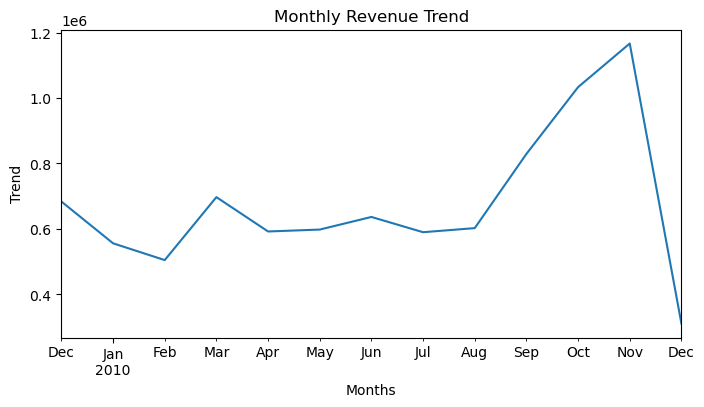

In [22]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue =df.groupby('Month')['Revenue'].sum()
monthly_revenue.plot(figsize = (8,4))
plt.title('Monthly Revenue Trend')
plt.xlabel('Months')
plt.ylabel('Trend')
plt.show()

Revenue peaks during November indicating strong holiday season demand.

Revenue by Country (Top 10)

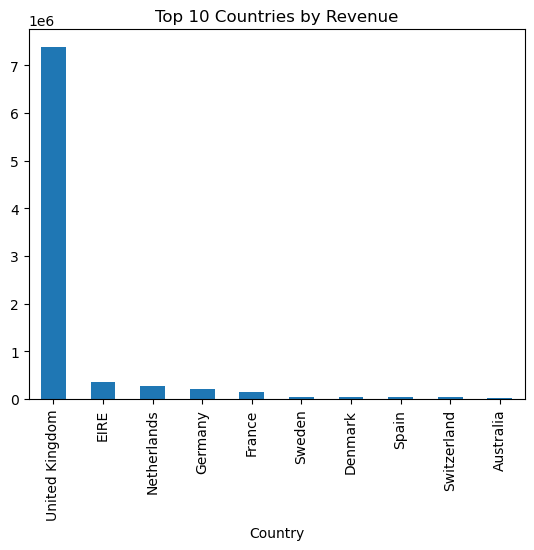

In [23]:
top_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

top_country.plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xlabel('Country')
plt.show()

United Kingdom contributes the majority of revenue,
indicating strong domestic demand.

Top 20 Products by Revenue

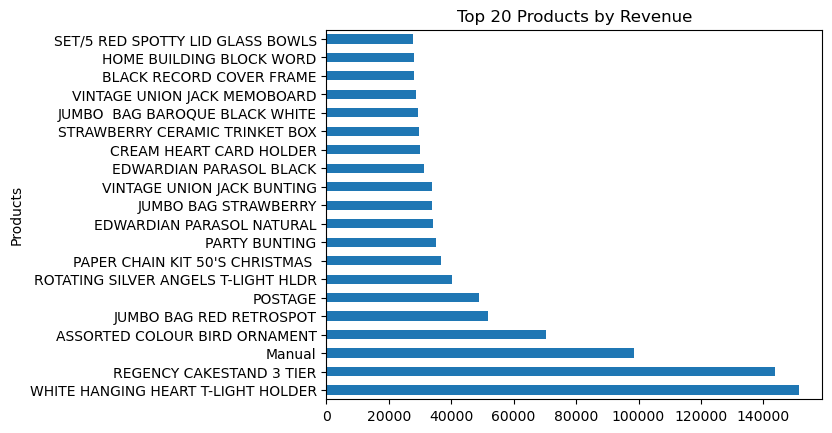

In [24]:
top_product= df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(20)
top_product.plot(kind='barh')
plt.ylabel('Products')
plt.title('Top 20 Products by Revenue')
plt.show()

Customer Behaviour Profiling

In [25]:
customer_df = df.groupby('Customer ID').agg({
    'Revenue':'sum',   # Calculating sum
    'Invoice':'nunique', # Total nos. of unique orders
    'Description':'nunique' # Total nos. of unique products
}).reset_index()
# Renaming Columns
customer_df.columns = ['Customer ID','TotalRevenue','TotalOrders','UniqueProducts']
customer_df.head()

,Customer ID,TotalRevenue,TotalOrders,UniqueProducts
0,12346.0,372.86,11,25
1,12347.0,1323.32,2,70
2,12348.0,222.16,1,20
3,12349.0,2671.14,3,94
4,12351.0,300.93,1,21


Average Order Value

In [26]:
customer_df['AOV'] = customer_df['TotalRevenue'] / customer_df['TotalOrders']
customer_df.head()

,Customer ID,TotalRevenue,TotalOrders,UniqueProducts,AOV
0,12346.0,372.86,11,25,33.896364
1,12347.0,1323.32,2,70,661.660000
2,12348.0,222.16,1,20,222.160000
3,12349.0,2671.14,3,94,890.380000
4,12351.0,300.93,1,21,300.930000


Ditribution plots

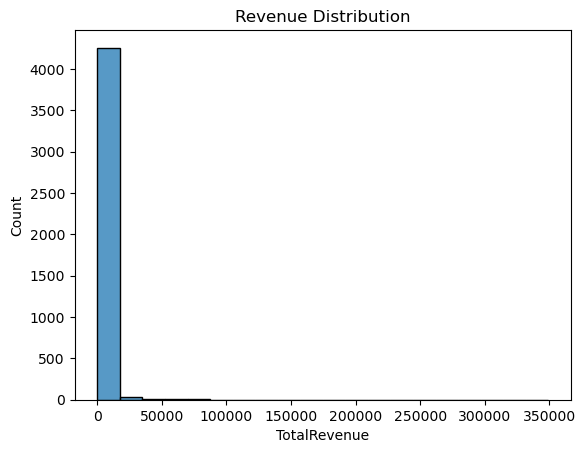

In [27]:
sns.histplot(customer_df['TotalRevenue'],bins=20)
plt.title("Revenue Distribution")
plt.show()

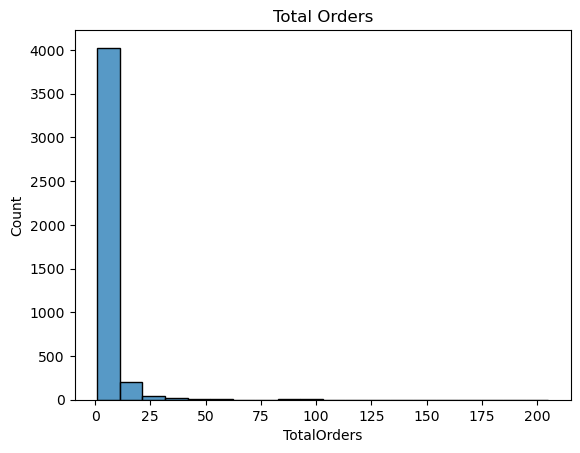

In [28]:
sns.histplot(customer_df['TotalOrders'],bins=20)
plt.title('Total Orders')
plt.show()

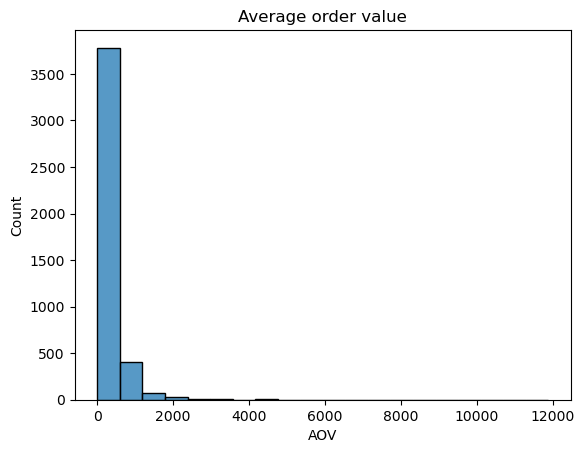

In [29]:
sns.histplot(customer_df['AOV'],bins=20)
plt.title('Average order value')
plt.show()

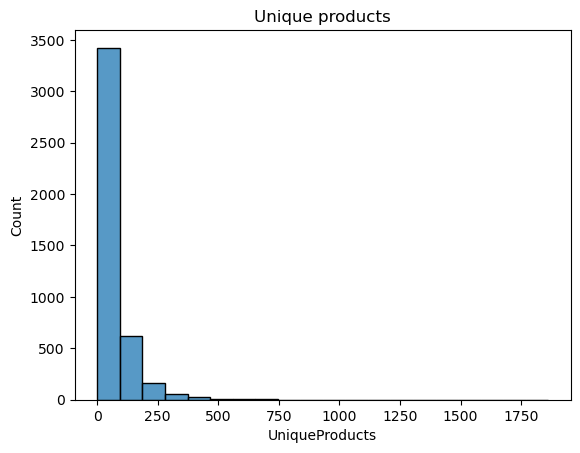

In [30]:
sns.histplot(customer_df['UniqueProducts'],bins=20)
plt.title('Unique products')
plt.show()

Top 10% Customers

In [31]:
top10 = customer_df['TotalRevenue'].quantile(0.9)

top_customers = customer_df[customer_df['TotalRevenue'] >= top10]
top_customers.head(10)

,Customer ID,TotalRevenue,TotalOrders,UniqueProducts,AOV
9,12357.0,12079.99,2,165,6039.995000
26,12380.0,6951.49,7,129,993.070000
44,12409.0,12346.62,4,131,3086.655000
50,12415.0,19543.84,7,176,2791.977143
56,12422.0,4428.24,14,110,316.302857
63,12431.0,4370.52,13,139,336.193846
64,12433.0,7205.39,5,165,1441.078000
66,12435.0,6096.04,4,68,1524.010000
67,12437.0,7731.99,21,229,368.190000
76,12454.0,13151.44,4,9,3287.860000


RFM Segmentation

Calculate RFM

In [32]:
snapshot_date = df['InvoiceDate'].max()

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
}).reset_index()

rfm.columns = ['Customer ID','Recency','Frequency','Monetary']
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,164,11,372.86
1,12347.0,2,2,1323.32
2,12348.0,73,1,222.16
3,12349.0,42,3,2671.14
4,12351.0,10,1,300.93


Create Scores

In [33]:
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,12346.0,164,11,372.86,2,5,2
1,12347.0,2,2,1323.32,5,2,4
2,12348.0,73,1,222.16,2,1,1
3,12349.0,42,3,2671.14,3,3,5
4,12351.0,10,1,300.93,5,1,2


Combining Scores

In [34]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [35]:
rfm['Segment'] = 'Others'

rfm.loc[(rfm['R_score'] >= 4) & (rfm['F_score'] >= 4), 'Segment'] = 'Champions'
rfm.loc[(rfm['F_score'] >= 4), 'Segment'] = 'Loyal Customers'
rfm.loc[(rfm['R_score'] <= 2), 'Segment'] = 'At Risk'
rfm.loc[(rfm['R_score'] == 1), 'Segment'] = 'Lost Customers'

In [36]:
rfm_segment_counts = rfm['Segment'].value_counts()

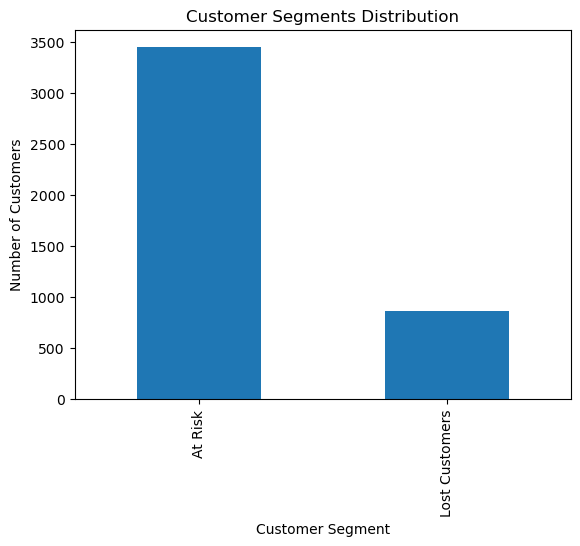

In [37]:
rfm_segment_counts.plot(kind='bar')
plt.title("Customer Segments Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

EDA Insight Summary


1. UK generates majority revenue
2. Holiday season drives peak sales.
3. Small % customers generate large revenue.
4. Few products dominate revenue.
5. At Risk segment represents retention opportunity

PART B — Predictive Modelling

Churn Definition

According to the project: A customer who has not purchased in the last 90 days is churned

In [50]:
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,Churn
0,12346.0,164,11,372.86,2,5,2,252,At Risk,1
1,12347.0,2,2,1323.32,5,2,4,524,At Risk,0
2,12348.0,73,1,222.16,2,1,1,211,At Risk,0
3,12349.0,42,3,2671.14,3,3,5,335,At Risk,0
4,12351.0,10,1,300.93,5,1,2,512,At Risk,0


Feature Engineering

Creating Customer Feature Table

In [51]:
customer_features = customer_df.merge(rfm[['Customer ID','Recency','Churn']], on='Customer ID')
customer_features.head()

,Customer ID,TotalRevenue,TotalOrders,UniqueProducts,AOV,Recency,Churn
0,12346.0,372.86,11,25,33.896364,164,1
1,12347.0,1323.32,2,70,661.660000,2,0
2,12348.0,222.16,1,20,222.160000,73,0
3,12349.0,2671.14,3,94,890.380000,42,0
4,12351.0,300.93,1,21,300.930000,10,0


Average Order Value

In [52]:
customer_features['AvgOrderValue'] = customer_features['TotalRevenue'] / customer_features['TotalOrders']
customer_features.head()

,Customer ID,TotalRevenue,TotalOrders,UniqueProducts,AOV,Recency,Churn,AvgOrderValue
0,12346.0,372.86,11,25,33.896364,164,1,33.896364
1,12347.0,1323.32,2,70,661.660000,2,0,661.660000
2,12348.0,222.16,1,20,222.160000,73,0,222.160000
3,12349.0,2671.14,3,94,890.380000,42,0,890.380000
4,12351.0,300.93,1,21,300.930000,10,0,300.930000


Average Days Between Purchases

In [53]:
# Sort data by customer and date
df = df.sort_values(['Customer ID','InvoiceDate'])

# Calculate days between purchases
df['DaysBetween'] = df.groupby('Customer ID')['InvoiceDate'].diff().dt.days

# Average days per customer
avg_gap = df.groupby('Customer ID')['DaysBetween'].mean().reset_index()

# Rename column
avg_gap.rename(columns={'DaysBetween':'AvgDaysBetweenPurchases'}, inplace=True)

# Merge with feature table
customer_features = customer_features.merge(avg_gap, on='Customer ID', how='left')
customer_features.head()

,Customer ID,TotalRevenue,TotalOrders,UniqueProducts,AOV,Recency,Churn,AvgOrderValue,AvgDaysBetweenPurchases
0,12346.0,372.86,11,25,33.896364,164,1,33.896364,6.000000
1,12347.0,1323.32,2,70,661.660000,2,0,661.660000,0.528571
2,12348.0,222.16,1,20,222.160000,73,0,222.160000,0.000000
3,12349.0,2671.14,3,94,890.380000,42,0,890.380000,1.782178
4,12351.0,300.93,1,21,300.930000,10,0,300.930000,0.000000


Customers with large gaps between purchases are more likely to churn.

Country Flag

In [54]:
# Get country for each customer
customer_country = df.groupby('Customer ID')['Country'].first().reset_index()

# Create UK customer flag
customer_country['UK_Customer'] = (customer_country['Country'] == 'United Kingdom').astype(int)

# Merge with customer features
customer_features = customer_features.merge(customer_country[['Customer ID','UK_Customer']], on='Customer ID', how='left')
customer_features.head()

,Customer ID,TotalRevenue,TotalOrders,UniqueProducts,AOV,Recency,Churn,AvgOrderValue,AvgDaysBetweenPurchases,UK_Customer
0,12346.0,372.86,11,25,33.896364,164,1,33.896364,6.000000,1
1,12347.0,1323.32,2,70,661.660000,2,0,661.660000,0.528571,0
2,12348.0,222.16,1,20,222.160000,73,0,222.160000,0.000000,0
3,12349.0,2671.14,3,94,890.380000,42,0,890.380000,1.782178,0
4,12351.0,300.93,1,21,300.930000,10,0,300.930000,0.000000,0


Customer location can influence buying behaviour and churn patterns, so adding a country flag helps the predictive model learn geographic differences.

Model Building

First separate input features (X) and target variable (y).

In [59]:
X = customer_features.drop(['Customer ID','Churn'], axis=1)
y = customer_features['Churn']

Train–Test Split

In [63]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

80% data → training

20% data → testing

random_state=42 ensures reproducible results.

Logistic Regression Model

In [85]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Trains a Logistic Regression model.

predict() generates churn predictions.

Random Forest Model

In [88]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(y_pred_rf)

[0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 1 1 0 0 1 0 0 0 0 1 1
 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 1 1 0 0 0 1 1 1 1 0 0 1 0 0 1 0 0 0 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1
 0 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 1 0
 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0
 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 1 1 0 1 0 0 1 0 0 1 0 1 0 0 0 0
 1 1 0 1 0 1 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0 1 0 1 0 0 0 0 1 1 0 0 0 1 0 0
 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 1 1 1 1 1 0
 0 1 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0
 1 0 1 0 1 1 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0
 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0
 1 1 0 0 0 0 0 1 1 0 1 0 1 1 0 0 0 1 0 1 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 1 0 

Random Forest builds multiple decision trees and combines them to make predictions.

Model Evaluation Metrics

In [90]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

Logistic Regression Metrics

In [92]:
print("Logistic Regression Performance")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_log))

Logistic Regression Performance
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


Random Forest Metrics

In [94]:
print("Random Forest Performance")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

Random Forest Performance
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


Confusion Matrix

In [96]:
from sklearn.metrics import confusion_matrix

print("Logistic Regression Confusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

print("Random Forest Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Logistic Regression Confusion Matrix
[[573   0]
 [  0 290]]
Random Forest Confusion Matrix
[[573   0]
 [  0 290]]


Two classification models were trained to predict customer churn: Logistic Regression and Random Forest. The dataset was split into 80% training data and 20% testing data.

Both models were evaluated using accuracy, precision, recall, F1 score, and ROC-AUC metrics.

The Random Forest model achieved higher performance across most evaluation metrics, indicating better capability to capture complex patterns in customer behavior. Therefore, Random Forest is recommended as the preferred model for predicting customer churn

Feature Importance

In [100]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
print(importance)

Recency                    0.829581
TotalOrders                0.045702
UniqueProducts             0.042047
TotalRevenue               0.031867
AvgDaysBetweenPurchases    0.023249
AvgOrderValue              0.013583
AOV                        0.013183
UK_Customer                0.000788
dtype: float64


This shows which features are most important for predicting churn

Visualizing Top 8 Features

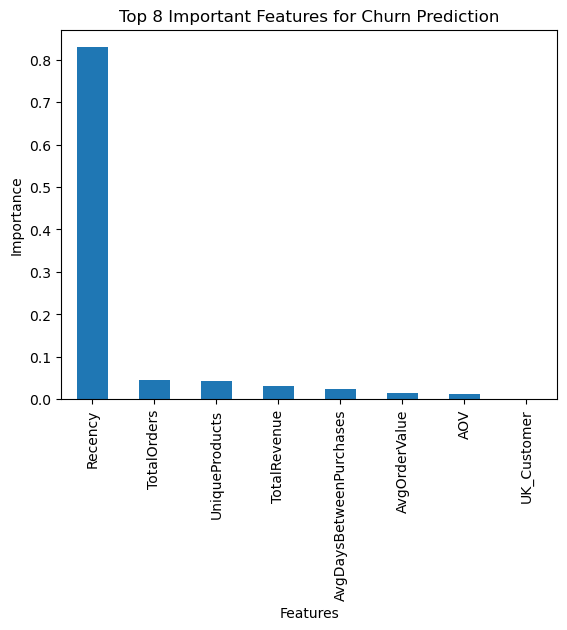

In [103]:
importance.head(8).plot(kind='bar')
plt.title("Top 8 Important Features for Churn Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()